# Week 4 - Task 1
# Ensemble Learning: Random Forest vs XGBoost

This task compares Random Forest and XGBoost ensemble learning models
with the Logistic Regression model used in previous tasks.

In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Select useful features
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

X = df[features].copy()
y = df["Survived"]

In [5]:
# Fill missing numerical values
X["Age"] = X["Age"].fillna(X["Age"].median())

# Fill missing categorical values
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [7]:
X = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True)

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [8]:
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nMissing values:")
print(X.isnull().sum())

Number of rows: 891
Number of features: 8

Missing values:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines many
decision trees. Each tree makes a prediction, and the final prediction
is based on the combined results of the trees.

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [11]:
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 81.56%


In [12]:
print("Random Forest Classification Report:\n")

print(classification_report(y_test, rf_pred))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



## XGBoost Classifier

XGBoost is another ensemble learning algorithm based on decision trees.
Instead of building independent trees like Random Forest, XGBoost builds
trees sequentially, with each new tree trying to improve the errors made
by previous trees.

In [13]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [14]:
xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print(f"XGBoost Accuracy: {xgb_accuracy:.2%}")

XGBoost Accuracy: 79.33%


In [15]:
print("XGBoost Classification Report:\n")

print(classification_report(y_test, xgb_pred))

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       110
           1       0.80      0.62      0.70        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.79       179



In [16]:
# Earlier Logistic Regression result
logistic_accuracy = 0.8101

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(4)

comparison

,Model,Accuracy
0,Logistic Regression,0.8101
1,Random Forest,0.8156
2,XGBoost,0.7933


In [17]:
comparison_display = comparison.copy()

comparison_display["Accuracy"] = (
    comparison_display["Accuracy"] * 100
).round(2).astype(str) + "%"

comparison_display

,Model,Accuracy
0,Logistic Regression,81.01%
1,Random Forest,81.56%
2,XGBoost,79.33%


In [18]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance

,0
Fare,0.278484
Sex_male,0.263240
Age,0.252361
Pclass,0.079478
SibSp,0.053489
Parch,0.041017
Embarked_S,0.023194
Embarked_Q,0.008736


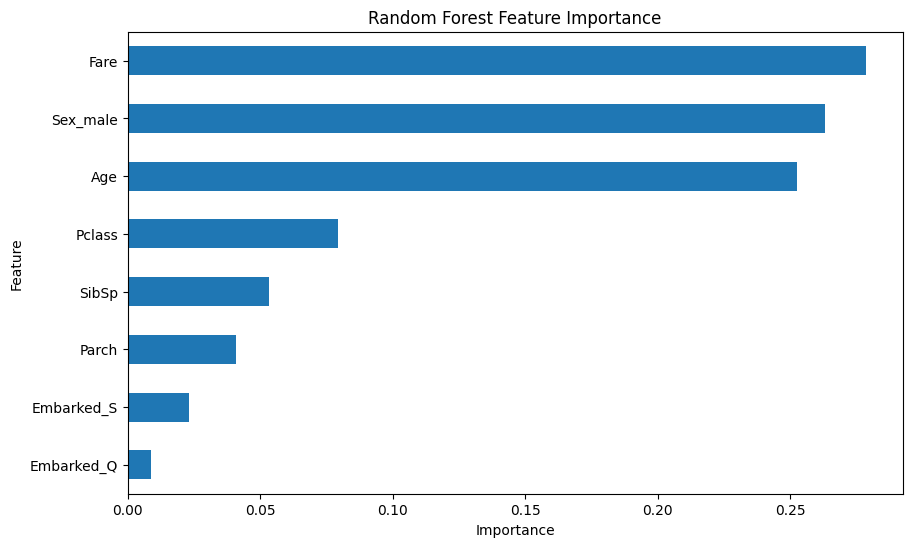

In [19]:
plt.figure(figsize=(10, 6))

rf_importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [20]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importance

,0
Sex_male,0.598314
Pclass,0.185756
Embarked_S,0.058747
Age,0.051126
SibSp,0.048257
Fare,0.042821
Parch,0.013241
Embarked_Q,0.001739


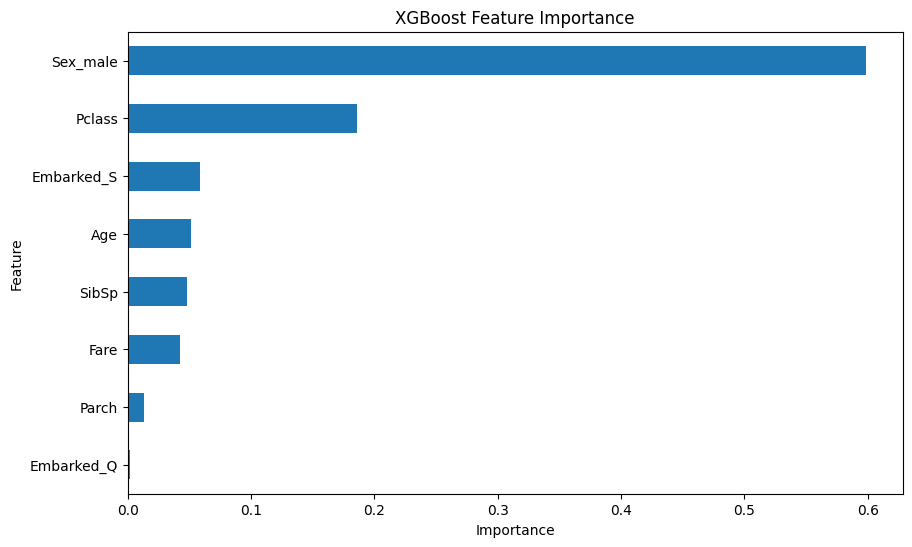

In [21]:
plt.figure(figsize=(10, 6))

xgb_importance.sort_values().plot(kind="barh")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [22]:
print("Top 5 Random Forest Features:")
print(rf_importance.head(5))

print("\nTop 5 XGBoost Features:")
print(xgb_importance.head(5))

Top 5 Random Forest Features:
Fare        0.278484
Sex_male    0.263240
Age         0.252361
Pclass      0.079478
SibSp       0.053489
dtype: float64

Top 5 XGBoost Features:
Sex_male      0.598314
Pclass        0.185756
Embarked_S    0.058747
Age           0.051126
SibSp         0.048257
dtype: float32


## Random Forest vs XGBoost

Random Forest combines many decision trees that are trained independently
and combines their predictions to make a more reliable final prediction.
XGBoost builds trees sequentially, where each new tree focuses on improving
the mistakes made by the previous trees. Random Forest mainly reduces
overfitting by averaging many trees, while XGBoost uses boosting to improve
prediction accuracy step by step.

## Feature Importance Comparison

The feature importance plots show which Titanic features contributed most
to the predictions of Random Forest and XGBoost. Both models can identify
important passenger characteristics, but their rankings may differ because
the two algorithms build their trees differently. Features with higher
importance had a greater influence on the models' predictions.

## Conclusion

The ensemble models were compared with the Logistic Regression model from
the previous task. Random Forest and XGBoost can capture more complex
relationships between the Titanic features than a simple linear
classification model. The model with the highest test accuracy performed
best on this dataset, although accuracy alone does not completely describe
model performance.

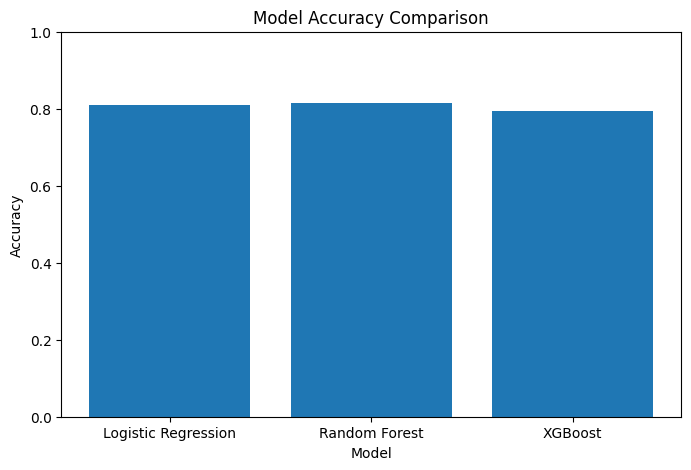

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()